In [2]:
"""Analyze public app store reviews of DB Navigator to identify user satisfaction, recurring complaints, and factors influencing user engagement. Apply text mining and sentiment analysis to extract actionable insights that can guide the design of user-centered digital public services."""
# =========================================================
# DB NAVIGATOR APP REVIEW ANALYSIS
#
# Research Goal:
# Analyze public app store reviews of DB Navigator to identify
# user satisfaction, recurring complaints, feature requests,
# and factors influencing user engagement.
#
# Apply text mining and sentiment analysis to extract
# actionable insights that can guide the design and
# improvement of user-centered digital public services.
#
# Research Questions:
# - What aspects of DB Navigator do users value most?
# - What are the most common sources of user frustration?
# - Which topics have the greatest impact on user satisfaction?
#
# Dataset:
# Public Google Play Store reviews of DB Navigator
# (App ID: de.hafas.android.db)
#
# =========================================================

'Analyze public app store reviews of DB Navigator to identify user satisfaction, recurring complaints, and factors influencing user engagement. Apply text mining and sentiment analysis to extract actionable insights that can guide the design of user-centered digital public services.'

In [ ]:
# =========================================================
# 1. INSTALL REQUIRED LIBRARIES
#
# Run this only once.
# These libraries are used for:
#
# - data analysis
# - visualization
# - text mining
# - sentiment analysis
# - topic modeling
#
# =========================================================
#!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud textblob

# =========================================================
# 2. IMPORT LIBRARIES
#
# pandas      -> data handling
# numpy       -> numerical operations
# matplotlib  -> plotting
# seaborn     -> better visualizations
# Counter     -> count word frequencies
# WordCloud   -> generate word clouds
# sklearn     -> topic modeling
# TextBlob    -> sentiment analysis
# nltk        -> stopwords
# re          -> text cleaning with regex
#
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from collections import Counter
from wordcloud import WordCloud

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from textblob import TextBlob

import nltk
from nltk.corpus import stopwords

import re

# =========================================================
# 3. DOWNLOAD NLTK STOPWORDS
#
# Stopwords are common words like:
# "und", "oder", "der", "die"
#
# These words do not carry much meaning
# for text mining.
#
# =========================================================

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/amir/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [4]:
# =========================================================
# 4. LOAD DATASET
#
# Read the CSV file containing app reviews.
#
# =========================================================

reviews = pd.read_csv("data/db_navigator_reviews.csv")

In [5]:
# =========================================================
# 5. VIEW FIRST ROWS
#
# Quick inspection of the dataset.
#
# head() shows the first 5 rows.
#
# =========================================================

reviews.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,14fec7bb-b9d0-42ec-a449-ae767dafc58e,Oliver Bschor,https://play-lh.googleusercontent.com/a/ACg8oc...,völlig unübersichtliche Bedienoberfläche,1,0,26.11.0,2026-06-27 15:08:36,NaN,NaN,26.11.0
1,f7f95b83-a988-4d69-82b3-e4a63bd34aef,Heike Veit,https://play-lh.googleusercontent.com/a-/ALV-U...,Gute Bedienbarkeit.,5,0,26.11.0,2026-06-27 12:41:37,NaN,NaN,26.11.0
2,8f966e81-dca5-4076-87b7-42e1a9cf69e1,Thomas Lichtenfeld,https://play-lh.googleusercontent.com/a/ACg8oc...,Soweit ok.,4,0,NaN,2026-06-27 12:01:03,NaN,NaN,NaN
3,a5275f68-dc30-46c6-916e-711fe01fe51c,Gerd Urban,https://play-lh.googleusercontent.com/a-/ALV-U...,"Einloggen nicht möglich, Seite öffnet sich nic...",1,0,26.11.0,2026-06-27 11:49:13,NaN,NaN,26.11.0
4,8346cb9e-7ab6-4d92-8664-0b102d04eb98,R Manz,https://play-lh.googleusercontent.com/a/ACg8oc...,An sich hat bisher immer alles gut funktionier...,3,0,26.11.0,2026-06-27 10:41:27,NaN,NaN,26.11.0


In [6]:
# =========================================================
# 6. BASIC DATASET INFORMATION
#
# - shape      -> number of rows and columns
# - columns    -> dataset column names
# - isnull()   -> missing values
#
# =========================================================

print("Dataset Shape:")
print(reviews.shape)

print("\nColumns:")
print(reviews.columns)

print("\nMissing Values:")
print(reviews.isnull().sum())
reviews['score'].value_counts().sort_index()

Dataset Shape:
(73518, 11)

Columns:
Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='str')

Missing Values:
reviewId                    0
userName                    0
userImage                   0
content                    76
score                       0
thumbsUpCount               0
reviewCreatedVersion     6205
at                          0
replyContent            57875
repliedAt               57875
appVersion               6205
dtype: int64


score
0       18
1    29605
2     7681
3     6260
4     8488
5    21466
Name: count, dtype: int64

In [7]:
# =========================================================
# 7. CLEAN DATASET
#
# Steps:
#
# 1. Remove rows with missing reviews
# 2. Convert review text to string
# 3. Remove duplicate reviews
#
# =========================================================

reviews = reviews.dropna(subset=["content"]).copy()

reviews["content"] = reviews["content"].astype(str)

reviews = reviews.drop_duplicates(subset=["content"])


# =========================================================
# 8. LOAD GERMAN STOPWORDS
#
# Stopwords are removed because they appear
# very frequently but provide little semantic value.
#
# Additional domain-specific stopwords are added
# manually for DB Navigator reviews.
#
# =========================================================

stop_words = set(stopwords.words("german"))

custom_stopwords = {
    "app",
    "apps",
    "db",
    "navigator",
    "bahn",

    "sehr",
    "mehr",
    "schon",
    "einfach",
    "immer",
    "eigentlich",
    "wirklich",
    "mal",
    "gibt",
    "wurde",
    "finde",
    "wäre",
}

stop_words.update(custom_stopwords)


# =========================================================
# 9. TEXT PREPROCESSING FUNCTION
#
# This function cleans review text.
#
# Steps:
#
# 1. Convert text to lowercase
# 2. Remove URLs
# 3. Remove numbers
# 4. Remove punctuation and special characters
# 5. Tokenize text
# 6. Remove stopwords
#
# =========================================================

def preprocess_text(text):

    # convert text to lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r"http\S+", "", text)

    # remove numbers
    text = re.sub(r"\d+", "", text)

    # remove punctuation/special characters
    text = re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", "", text)

    # tokenize
    tokens = text.split()

    # remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # join tokens back into text
    return " ".join(tokens).strip()


# =========================================================
# 10. APPLY TEXT CLEANING
#
# Create a new column:
#
# clean_text
#
# containing the cleaned review text.
#
# =========================================================

reviews["clean_text"] = reviews["content"].apply(preprocess_text)


# =========================================================
# 11. COMPARE ORIGINAL VS CLEANED TEXT
#
# Useful for verifying preprocessing quality.
#
# =========================================================

reviews[["content", "clean_text"]].head()

,content,clean_text
0,völlig unübersichtliche Bedienoberfläche,völlig unübersichtliche bedienoberfläche
1,Gute Bedienbarkeit.,gute bedienbarkeit
2,Soweit ok.,soweit ok
3,"Einloggen nicht möglich, Seite öffnet sich nic...",einloggen möglich seite öffnet woche
4,An sich hat bisher immer alles gut funktionier...,bisher gut funktioniert seit letzten android u...


In [8]:
# =========================================================
# 12. DEFINE FEATURE KEYWORDS
#
# Manually define important feature categories
# for DB Navigator.
#
# These keywords help identify:
#
# - usability issues
# - technical problems
# - ticketing experience
# - journey planning
# - user expectations
#
# The categories are later used to measure
# how frequently users discuss each topic.
#
# =========================================================

feature_keywords = {

    # -----------------------------------------------------
    # USER EXPERIENCE / USABILITY
    # -----------------------------------------------------
    "Usability": [

        "übersichtlich",
        "bedienung",
        "benutzerfreundlich",
        "einfach",
        "simpel",
        "verständlich",
        "klar",
        "intuitiv",
        "navigation",
        "oberfläche"
    ],

    # -----------------------------------------------------
    # TECHNICAL PROBLEMS / BUGS
    # -----------------------------------------------------
    "Bug Reports": [

        "bug",
        "bugs",
        "fehler",
        "absturz",
        "abgestürzt",
        "crash",
        "problem",
        "probleme",
        "hängt",
        "langsam",
        "update",
        "lade",
        "störung",
        "funktioniert"
    ],

    # -----------------------------------------------------
    # PERFORMANCE / STABILITY
    # -----------------------------------------------------
    "Performance": [

        "schnell",
        "langsam",
        "stabil",
        "instabil",
        "performance",
        "ladezeit",
        "reaktion",
        "flüssig",
        "hängt"
    ],

    # -----------------------------------------------------
    # JOURNEY PLANNING
    # -----------------------------------------------------
    "Journey Planning": [

        "verbindung",
        "route",
        "fahrplan",
        "reise",
        "umsteigen",
        "bahnhof",
        "ankunft",
        "abfahrt",
        "ziel",
        "strecke"
    ],

    # -----------------------------------------------------
    # TICKETS & BOOKING
    # -----------------------------------------------------
    "Tickets": [

        "ticket",
        "tickets",
        "buchen",
        "buchung",
        "reservierung",
        "zahlung",
        "bezahlen",
        "preis",
        "qr",
        "barcode"
    ],

    # -----------------------------------------------------
    # LOGIN & ACCOUNT
    # -----------------------------------------------------
    "Account": [

        "login",
        "anmelden",
        "abmelden",
        "konto",
        "passwort",
        "registrieren",
        "profil"
    ],

    # -----------------------------------------------------
    # DELAYS & NOTIFICATIONS
    # -----------------------------------------------------
    "Delays & Notifications": [

        "verspätung",
        "verspätet",
        "ausfall",
        "benachrichtigung",
        "push",
        "meldung",
        "informationen",
        "warnung",
        "update"
    ],

    # -----------------------------------------------------
    # RELIABILITY
    # -----------------------------------------------------
    "Reliability": [

        "zuverlässig",
        "verlässlich",
        "genau",
        "fehlerhaft",
        "funktioniert",
        "unzuverlässig",
        "korrekt"
    ],

    # -----------------------------------------------------
    # DESIGN / INTERFACE
    # -----------------------------------------------------
    "Design": [

        "design",
        "layout",
        "optik",
        "modern",
        "oberfläche",
        "ansicht",
        "darstellung"
    ],

    # -----------------------------------------------------
    # FEATURE REQUESTS
    # -----------------------------------------------------
    "Feature Requests": [

        "wunsch",
        "funktion",
        "feature",
        "verbessern",
        "fehlt",
        "hinzufügen",
        "erweitern",
        "möglichkeit"
    ]
}

Positive feature mentions:

                  Feature  Mentions  Percentage
0               Usability      1629    6.670215
1             Bug Reports      3669   15.023340
2             Performance      1513    6.195234
3        Journey Planning      1642    6.723446
4                 Tickets      2119    8.676603
5                 Account       191    0.782082
6  Delays & Notifications      1595    6.530997
7             Reliability      3298   13.504218
8                  Design       309    1.265253
9        Feature Requests       779    3.189747

Negative feature mentions:

                  Feature  Mentions  Percentage
0               Usability       826    2.238968
1             Bug Reports     11424   30.966063
2             Performance      1211    3.282554
3        Journey Planning      4759   12.899816
4                 Tickets      8905   24.138025
5                 Account      2861    7.755069
6  Delays & Notifications      7479   20.272688
7             Reliability      

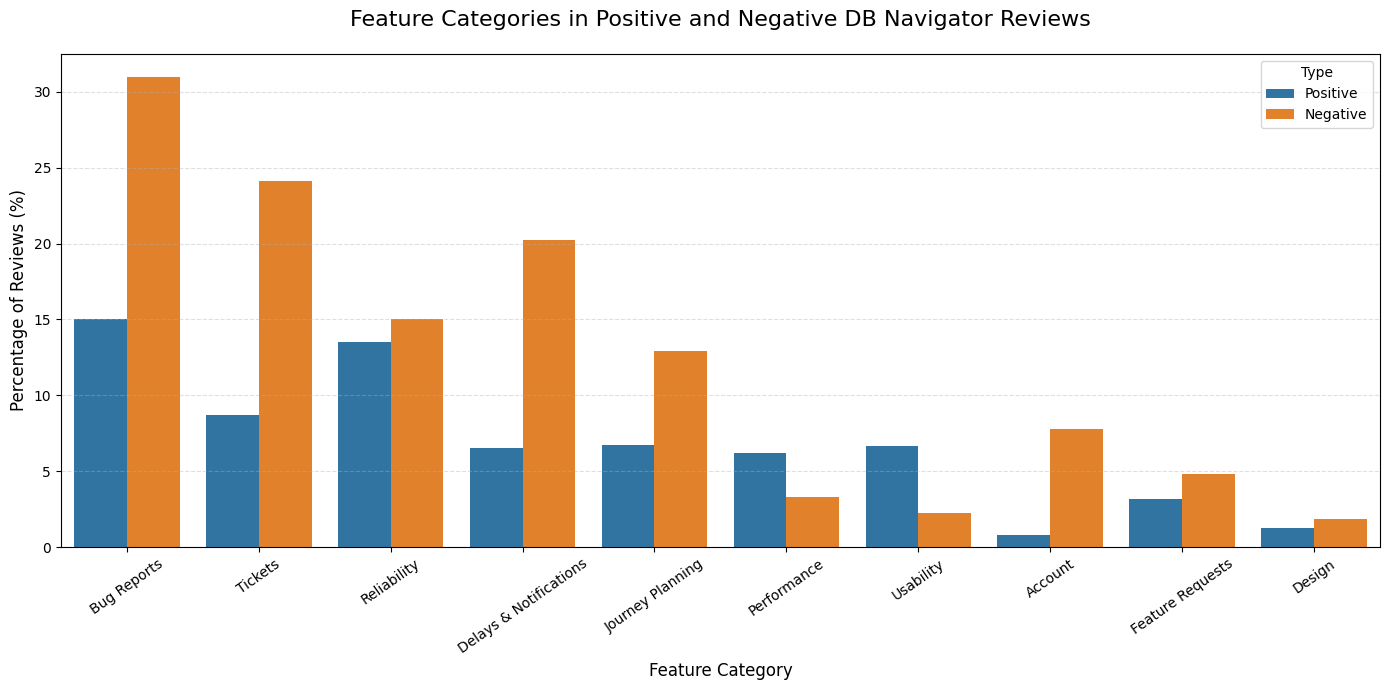

In [11]:
# =========================================================
# FEATURE KEYWORD ANALYSIS
#
# Goal:
# Compare which DB Navigator feature categories
# are discussed in positive and negative reviews.
#
# This helps identify:
#
# - highly appreciated functionalities
# - recurring user frustrations
# - areas requiring improvement
#
# =========================================================


# =========================================================
# 1. CREATE FEATURE COUNT FUNCTION
# =========================================================

def count_feature_mentions(dataframe, feature_keywords):

    results = {}

    for feature, keywords in feature_keywords.items():

        count = (
            dataframe["clean_text"]
            .apply(
                lambda text: any(
                    f" {keyword} " in f" {text} "
                    for keyword in keywords
                )
            )
            .sum()
        )

        results[feature] = count

    return pd.DataFrame(
        results.items(),
        columns=["Feature", "Mentions"]
    )


# =========================================================
# 2. SPLIT REVIEWS BY RATING
#
# Positive:
# ★★★★☆ and ★★★★★
#
# Neutral:
# ★★★☆☆
#
# Negative:
# ★☆☆☆☆ and ★★☆☆☆
#
# =========================================================

positive_reviews = reviews[reviews["score"] >= 4]

neutral_reviews = reviews[reviews["score"] == 3]

negative_reviews = reviews[reviews["score"] <= 2]


# =========================================================
# 3. FEATURE ANALYSIS
# =========================================================

positive_feature_df = count_feature_mentions(
    positive_reviews,
    feature_keywords
)

negative_feature_df = count_feature_mentions(
    negative_reviews,
    feature_keywords
)


# =========================================================
# 4. CALCULATE PERCENTAGES
#
# Normalize feature mentions by the total
# number of reviews in each sentiment group.
#
# =========================================================

positive_feature_df["Percentage"] = (
    positive_feature_df["Mentions"] / len(positive_reviews) * 100
)

negative_feature_df["Percentage"] = (
    negative_feature_df["Mentions"] / len(negative_reviews) * 100
)


# =========================================================
# 5. DISPLAY RESULTS
# =========================================================

print("Positive feature mentions:\n")
print(positive_feature_df)

print("\nNegative feature mentions:\n")
print(negative_feature_df)


# =========================================================
# 6. COMBINE DATA
# =========================================================

positive_feature_df["Type"] = "Positive"

negative_feature_df["Type"] = "Negative"

combined_df = pd.concat(
    [positive_feature_df, negative_feature_df],
    ignore_index=True
)


# =========================================================
# 7. SORT FEATURES
#
# Sort by overall percentage so the most
# discussed categories appear first.
#
# =========================================================

feature_order = (
    combined_df
    .groupby("Feature")["Percentage"]
    .sum()
    .sort_values(ascending=False)
    .index
)


# =========================================================
# 8. CREATE GROUPED BAR CHART
# =========================================================

plt.figure(figsize=(14, 7))

sns.barplot(
    data=combined_df,
    x="Feature",
    y="Percentage",
    hue="Type",
    order=feature_order
)

plt.title(
    "Feature Categories in Positive and Negative DB Navigator Reviews",
    fontsize=16,
    pad=20
)

plt.xlabel("Feature Category", fontsize=12)

plt.ylabel("Percentage of Reviews (%)", fontsize=12)

plt.xticks(rotation=35)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()

In [12]:
# =========================================================
# TOPIC MODELING USING LATENT DIRICHLET ALLOCATION (LDA)
#
# Goal:
# Discover the main discussion topics in
# positive and negative DB Navigator reviews.
#
# =========================================================


# =========================================================
# 1. SPLIT REVIEWS BY RATING
#
# Positive reviews:
# Ratings 4-5
#
# Neutral reviews:
# Rating 3
#
# Negative reviews:
# Ratings 1-2
#
# =========================================================

positive_reviews = reviews[reviews["score"] >= 4]

neutral_reviews = reviews[reviews["score"] == 3]

negative_reviews = reviews[reviews["score"] <= 2]


# =========================================================
# 2. POSITIVE REVIEW TOPIC MODELING
#
# Discover which aspects of DB Navigator
# users appreciate most.
#
# =========================================================

print("\n================ POSITIVE TOPICS ================\n")

vectorizer_pos = CountVectorizer(
    max_df=0.90,
    min_df=5,
    max_features=5000,
    stop_words=list(stop_words)
)

X_pos = vectorizer_pos.fit_transform(
    positive_reviews["clean_text"]
)

lda_pos = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda_pos.fit(X_pos)

feature_names_pos = vectorizer_pos.get_feature_names_out()

for topic_idx, topic in enumerate(lda_pos.components_):

    print(f"\nPositive Topic {topic_idx + 1}")

    top_words = [
        feature_names_pos[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(", ".join(top_words))


# =========================================================
# 3. NEGATIVE REVIEW TOPIC MODELING
#
# Discover the major problems and
# recurring user frustrations.
#
# =========================================================

print("\n================ NEGATIVE TOPICS ================\n")

vectorizer_neg = CountVectorizer(
    max_df=0.90,
    min_df=5,
    max_features=5000,
    stop_words=list(stop_words)
)

X_neg = vectorizer_neg.fit_transform(
    negative_reviews["clean_text"]
)

lda_neg = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

lda_neg.fit(X_neg)

feature_names_neg = vectorizer_neg.get_feature_names_out()

for topic_idx, topic in enumerate(lda_neg.components_):

    print(f"\nNegative Topic {topic_idx + 1}")

    top_words = [
        feature_names_neg[i]
        for i in topic.argsort()[:-11:-1]
    ]

    print(", ".join(top_words))


================ POSITIVE TOPICS ================


Positive Topic 1
funktioniert, schnell, zufrieden, super, gut, zuverlässig, läuft, tickets, klasse, einwandfrei

Positive Topic 2
gut, super, verbindungen, gute, top, angezeigt, praktisch, ganz, empfehlen, zeigt

Positive Topic 3
übersichtlich, besser, macht, super, probleme, gute, zufrieden, hilfreich, danke, nutze

Positive Topic 4
zug, perfekt, ticket, beste, verspätung, bus, informationen, buchen, tickets, wann

Positive Topic 5
super, bedienen, update, angezeigt, funktioniert, seit, sterne, leicht, gut, klappt

================ NEGATIVE TOPICS ================


Negative Topic 1
möglich, tickets, buchen, ticket, kaufen, bahncard, warum, buchung, leider, fahrt

Negative Topic 2
ticket, funktioniert, tickets, kaufen, geht, anmelden, einloggen, passwort, login, neu

Negative Topic 3
zug, angezeigt, verspätungen, verspätung, züge, zeigt, fahren, verbindungen, minuten, bus

Negative Topic 4
seit, update, bitte, ab, funktioniert, stür

In [11]:
"""Analyze public app store reviews of existing smart city and municipal applications from German cities (for example: Mängelmelder). Apply text mining and sentiment analysis to identify what citizens value, what frustrates them, and which features drive engagement. The goal is to extract actionable priorities that Ilmenau can use to guide its own smart city service development and SensBee feature roadmap."""


'Analyze public app store reviews of existing smart city and municipal applications from German cities (for example: Mängelmelder). Apply text mining and sentiment analysis to identify what citizens value, what frustrates them, and which features drive engagement. The goal is to extract actionable priorities that Ilmenau can use to guide its own smart city service development and SensBee feature roadmap.'

# DB Navigator Review Analysis Findings

=========================================================

## Research Topic

Analyze public app store reviews of **DB Navigator** to identify user satisfaction, recurring complaints, feature requests, and factors influencing user engagement.

Apply text mining and sentiment analysis to:

* identify what users value,
* identify common sources of frustration,
* identify which features have the greatest impact on user satisfaction.

The goal is to extract actionable insights that can support the design and improvement of user-centered digital public services.

**Dataset:**
Public Google Play Store reviews of DB Navigator

=========================================================

# Positive Topics Interpretation (What Users Value)

## Positive Topic 1 — Reliable Performance

**Keywords:**

* funktioniert *(works)*
* schnell *(fast)*
* zuverlässig *(reliable)*
* läuft *(runs)*
* tickets *(tickets)*

Users appreciate reliable application performance, fast response times, and dependable ticket functionality.

---

## Positive Topic 2 — Journey Planning

**Keywords:**

* verbindungen *(connections)*
* angezeigt *(displayed)*
* praktisch *(practical)*
* zeigt *(shows)*
* empfehlen *(recommend)*

Users value accurate journey planning, clear connection information, and practical travel assistance.

---

## Positive Topic 3 — Ease of Use

**Keywords:**

* übersichtlich *(well organized)*
* bedienen *(easy to use)*
* hilfreich *(helpful)*
* funktioniert *(works)*
* besser *(better)*

Users appreciate an intuitive interface and an application that is easy to navigate during travel.

---

## Positive Topic 4 — Ticket Management

**Keywords:**

* ticket *(ticket)*
* buchen *(book)*
* informationen *(information)*
* verspätung *(delay)*
* zug *(train)*

Users positively evaluate convenient ticket purchasing and integrated travel information.

---

# Negative Topics Interpretation (What Frustrates Users)

## Negative Topic 1 — Ticket Booking Problems

**Keywords:**

* tickets *(tickets)*
* buchen *(book)*
* kaufen *(buy)*
* bahncard *(BahnCard)*
* buchung *(booking)*

Many users report problems purchasing tickets, managing bookings, or using BahnCard-related features.

---

## Negative Topic 2 — Problems After Updates

**Keywords:**

* update *(update)*
* seit *(since)*
* funktioniert *(works)*
* stürzt *(crashes)*
* version *(version)*

Many negative reviews describe new problems introduced after application updates, including crashes and missing functionality.

---

## Negative Topic 3 — Journey Planning Issues

**Keywords:**

* verbindungen *(connections)*
* angezeigt *(displayed)*
* verbindung *(connection)*
* fehler *(error)*
* leider *(unfortunately)*

Users report incorrect connection information, missing journeys, or inaccurate travel planning.

---

## Negative Topic 4 — Technical Reliability

**Keywords:**

* fehler *(error)*
* funktioniert *(works)*
* stürzt *(crashes)*
* unübersichtlich *(confusing)*
* beheben *(fix)*

Users frequently experience technical issues, instability, and usability problems that reduce confidence in the application.

---

# Features Influencing User Satisfaction

The analysis indicates that user satisfaction in DB Navigator is primarily influenced by:

* ticket purchasing and management,
* journey planning,
* application reliability,
* delay notifications,
* performance and stability,
* usability.

These feature categories receive the highest number of mentions across both positive and negative reviews, indicating that they strongly influence the overall user experience. The results suggest that users place the greatest value on dependable operation, accurate travel information, and seamless ticket management, while technical failures and problems introduced through application updates remain the primary sources of dissatisfaction.
